In [1]:
#Time Series Analysis - EDA - Exploratory Data Analysis

In [2]:
#pip install yfinance

In [3]:
#pip install nselib

In [4]:
#1.IMPORT CUSTOM MODULE
from Descriptive import Descriptive

# from → keyword used to import a specific part of a module instead of the whole module
# Descriptive (module) → the Python file/module named Descriptive.py, which contains custom-defined code
# import → keyword that loads the specified item into the current notebook
# Descriptive (class) → the class named Descriptive defined inside the Descriptive module, imported here for use

# This line imports the Descriptive class from the Descriptive module so its functions/methods can be used directly in this notebook.

In [5]:
#2.CREATE CLASS OBJECT
obj=Descriptive()

# obj → variable name used to store the created object
# = → assignment operator that assigns the right-side value to the left-side variable
# Descriptive() → calls the Descriptive class constructor to create a new object/instance

# This line creates an object named obj from the Descriptive class, allowing access to its methods and functionalities.

In [6]:
#3.FETCH STOCK HISTORICAL DATA (using yfinance)

import yfinance as yf
# import → keyword to load a full module
# yfinance (module) → Python library used to fetch stock market data from Yahoo Finance
# as → keyword used to assign an alias
# yf → alias name assigned to the yfinance module

stk_data = yf.download("TCS.NS", start="2021-06-01", end="2022-01-05")
# stk_data → variable name storing the fetched stock data
# = → assignment operator
# yf.download(...) → calls the download function to fetch historical stock data
# "TCS.NS" → stock symbol with .NS suffix (required for NSE-listed stocks on Yahoo Finance)
# start="2021-06-01" → parameter specifying the start date (format: YYYY-MM-DD)
# end="2022-01-05" → parameter specifying the end date (format: YYYY-MM-DD)

stk_data.columns = stk_data.columns.get_level_values(0)
# stk_data.columns → the current column labels of the DataFrame (returned as a MultiIndex by yfinance)
# = → assignment operator, reassigns the columns with a new value
# stk_data.columns.get_level_values(0) → extracts only the first level of the MultiIndex, dropping the ticker-name level

# This code imports yfinance, fetches historical stock price data for TCS (NSE) between 1 June 2021 and 5 January 2022, and flattens the column names.

[*********************100%***********************]  1 of 1 completed


In [7]:
#4.VIEW DATASET SUMMARY INFO

stk_data.info()
# stk_data → the DataFrame variable holding the fetched stock data
# . → dot operator used to access a method/attribute belonging to the object
# info() → DataFrame method that prints a concise summary: column names, non-null counts, data types, and memory usage

# This code displays a quick overview of stk_data — its columns, data types, and whether any missing values exist.

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 150 entries, 2021-06-01 to 2022-01-04
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   150 non-null    float64
 1   High    150 non-null    float64
 2   Low     150 non-null    float64
 3   Open    150 non-null    float64
 4   Volume  150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 7.0 KB


In [8]:
#5.DISPLAY DATASET

stk_data
# stk_data → the DataFrame variable holding the fetched stock data
# (no method/operator) → simply displays the DataFrame's contents directly in the notebook output

# This code prints out the full stk_data DataFrame — showing all the fetched stock's rows and columns (Open, High, Low, Close, Volume, etc.).

Price,Close,High,Low,Open,Volume
Date,,,,,
2021-06-01,2733.041992,2747.734326,2714.839048,2746.564264,1377441
2021-06-02,2712.628662,2738.632868,2700.103345,2731.178456,2240078
2021-06-03,2722.856201,2734.384771,2706.733514,2734.384771,1281706
2021-06-04,2725.024170,2736.379425,2708.771541,2711.371961,1836060
2021-06-07,2759.219727,2765.504077,2716.226231,2726.107745,2559821
...,...,...,...,...,...
2021-12-29,3215.738525,3237.715248,3207.296025,3213.606173,1456923
2021-12-30,3249.726074,3255.165857,3202.943945,3204.119023,1966475
2021-12-31,3253.730957,3272.574285,3247.594838,3257.604041,1207141


In [9]:
#6.EXTRACT 'LOW' PRICE COLUMN

low = stk_data["Low"]
# low → variable name used to store the extracted column
# = → assignment operator
# stk_data → the DataFrame holding the fetched stock data
# ["Low"] → indexing operator used to select the column named "Low"

# This code extracts the "Low" price column from stk_data and stores it in the variable low.

In [10]:
#7.SEPARATE QUANTITATIVE & QUALITATIVE COLUMNS

dataset = stk_data
# dataset → variable name used to store a reference to the stock data
# = → assignment operator
# stk_data → the DataFrame holding the fetched stock data

quan, qual = obj.segreQuanQual(dataset)
# quan → variable name to store the list of quantitative (numerical) column names
# qual → variable name to store the list of qualitative (categorical) column names
# , → comma used to unpack multiple return values into separate variables
# = → assignment operator
# obj → the object created from the Descriptive class
# . → dot operator used to access a method belonging to the object
# segreQuanQual(dataset) → custom method that scans the dataset and separates its columns into quantitative and qualitative lists

# This code uses the custom segreQuanQual() method to split stk_data's columns into quantitative (quan) and qualitative (qual) column-name lists.

The Quantitative Data: ['Close', 'High', 'Low', 'Open', 'Volume']
The Qualtitative Data []


In [11]:
#8.GENERATE DESCRIPTIVE STATISTICS

des_data = obj.descriptive_Analysis(dataset, quan)
# des_data → variable name to store the resulting descriptive statistics table
# = → assignment operator
# obj → the object created from the Descriptive class
# . → dot operator used to access a method belonging to the object
# descriptive_Analysis(dataset, quan) → custom method that computes descriptive statistics (like mean, median, std, min, max, etc.) 
# for the quantitative columns in dataset

# This code runs the custom descriptive_Analysis() method on the quantitative columns and stores the resulting statistics table in des_data.

E:\Hope AI Course\Time Series Analysis\Descriptive.py:24: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  des_data[i]["Null_count"]=dataset[i].isnull().sum()
E:\Hope AI Course\Time Series Analysis\Descriptive.py:25: FutureWarning: ChainedAssig

In [12]:
#9.DISPLAY DESCRIPTIVE STATISTICS

des_data
# des_data → the DataFrame variable holding the computed descriptive statistics table
# (no method/operator) → simply displays the DataFrame's contents directly in the notebook output

# This code prints out the full des_data DataFrame — showing stats like mean, median, mode, std, min, max, etc. for each quantitative column.

,Close,High,Low,Open,Volume
Null_count,0,0,0,0,0
NonNull_count,150,150,150,150,150
Total_Count,150,150,150,150,150
Mean,3052.596113,3079.571256,3025.772935,3051.747958,2405011.886667
Median,3059.573242,3090.658933,3036.138941,3058.507135,2036945.5
Mode,2712.628662,2734.384771,2700.103345,2711.371961,328991
Std,198.632129,201.785718,193.088094,196.699355,1316216.067846
Min,2712.628662,2734.384771,2700.103345,2711.371961,328991.0
Q1:25%,2864.931274,2888.593298,2836.923696,2867.961744,1674560.0
Q2:50%,3059.573242,3090.658933,3036.138941,3058.507135,2036945.5


In [13]:
#10.VIEW DESCRIPTIVE STATISTICS FOR 'LOW' COLUMN

des_data["Low"]
# des_data → the DataFrame variable holding the computed descriptive statistics table
# ["Low"] → indexing operator used to select the column named "Low"

# This code extracts and displays the descriptive statistics (mean, median, mode, std, min, max, etc.) specifically for the "Low" price column.

Null_count                 0
NonNull_count            150
Total_Count              150
Mean             3025.772935
Median           3036.138941
Mode             2700.103345
Std               193.088094
Min              2700.103345
Q1:25%           2836.923696
Q2:50%           3036.138941
Q3:75%           3172.157075
Q4:100%          3387.924051
IQR               335.233379
1.5Rule           502.850069
Lesser           2334.073627
Greater          3675.007144
Name: Low, dtype: object

In [14]:
#11.VIEW DESCRIPTIVE STATISTICS FOR 'HIGH' COLUMN

des_data["High"]
# des_data → the DataFrame variable holding the computed descriptive statistics table
# ["High"] → indexing operator used to select the column named "High"

# This code extracts and displays the descriptive statistics (mean, median, mode, std, min, max, etc.) specifically for the "High" price column.

Null_count                 0
NonNull_count            150
Total_Count              150
Mean             3079.571256
Median           3090.658933
Mode             2734.384771
Std               201.785718
Min              2734.384771
Q1:25%           2888.593298
Q2:50%           3090.658933
Q3:75%           3223.615628
Q4:100%          3466.019959
IQR               335.022331
1.5Rule           502.533496
Lesser           2386.059801
Greater          3726.149124
Name: High, dtype: object

In [15]:
#12.IMPORT NUMPY LIBRARY

import numpy as np
# import → keyword to load a full module
# numpy (module) → Python library used for numerical computing, arrays, and mathematical operations
# as → keyword used to assign an alias
# np → alias name assigned to the numpy module

# This line imports the numpy library (as np) so its numerical and array functions can be used in this notebook.

In [16]:
#13.CALCULATE 99TH PERCENTILE OF 'LOW' COLUMN

np.percentile(dataset["Low"], 99)
# np → alias for the numpy module
# . → dot operator used to access a function belonging to the module
# percentile(...) → numpy function that calculates the value below which a given percentage of data falls
# dataset["Low"] → selects the "Low" price column from dataset
# 99 → the percentile value to calculate (99th percentile)

# This code calculates the value below which 99% of the "Low" price data falls, helping identify near-maximum values/outliers.

3369.9517773656066

In [17]:
#14.CALCULATE 80TH PERCENTILE OF 'HIGH' COLUMN

np.percentile(dataset["High"], 80)
# np → alias for the numpy module
# . → dot operator used to access a function belonging to the module
# percentile(...) → numpy function that calculates the value below which a given percentage of data falls
# dataset["High"] → selects the "High" price column from dataset
# 80 → the percentile value to calculate (80th percentile)

# This code calculates the value below which 80% of the "High" price data falls, giving insight into the upper range of prices excluding extreme highs.

3275.4295810867397

In [19]:
#15.DEFINE FUNCTION TO CALCULATE PDF PROBABILITY WITH VISUALIZATION

def get_pdf_probability(dataset, startrange, endrange):
# def → keyword used to define a new function
# get_pdf_probability → name given to this custom function
# dataset, startrange, endrange → parameters the function accepts: the data column, and the lower/upper bounds of the range

    from matplotlib import pyplot
    # from → keyword to import a specific part of a module
    # matplotlib (module) → Python library for creating plots and visualizations
    # import → keyword that loads the specified item
    # pyplot → matplotlib's plotting interface, used to draw charts

    from scipy.stats import norm
    # from → keyword to import a specific part of a module
    # scipy.stats (module) → SciPy's statistics submodule, containing probability distributions
    # import → keyword that loads the specified item
    # norm → the normal (Gaussian) distribution class from scipy.stats

    import seaborn as sns
    # import → keyword to load a full module
    # seaborn (module) → Python library built on matplotlib for statistical data visualization
    # as → keyword used to assign an alias
    # sns → alias name assigned to the seaborn module

    ax = sns.distplot(dataset, kde=True, kde_kws={'color':'blue'}, color='Green')
    # ax → variable storing the plot axis object
    # = → assignment operator
    # sns.distplot(...) → seaborn function that draws a histogram with a distribution curve
    # dataset → the data column being plotted
    # kde=True → parameter enabling the Kernel Density Estimate curve (smooth distribution line)
    # kde_kws={'color':'blue'} → parameter setting the KDE line color to blue
    # color='Green' → parameter setting the histogram bar color to green

    pyplot.axvline(startrange, color='Red')
    # pyplot.axvline(...) → draws a vertical line on the plot at a given x-value
    # startrange → the x-position (lower bound) where the line is drawn
    # color='Red' → parameter setting the line color to red

    pyplot.axvline(endrange, color='Red')
    # pyplot.axvline(...) → draws a vertical line on the plot at a given x-value
    # endrange → the x-position (upper bound) where the line is drawn
    # color='Red' → parameter setting the line color to red

    # generate a sample
    sample = dataset
    # sample → variable name storing a copy/reference of dataset
    # = → assignment operator
    # dataset → the input data column

    # calculate parameters
    sample_mean = sample.mean()
    # sample_mean → variable name storing the average value
    # = → assignment operator
    # sample.mean() → method that calculates the mean of the sample

    sample_std = sample.std()
    # sample_std → variable name storing the standard deviation
    # = → assignment operator
    # sample.std() → method that calculates the standard deviation of the sample

    print('Mean=%.3f, Standard Deviation=%.3f' % (sample_mean, sample_std))
    # print(...) → displays text output
    # '%.3f' → string formatting placeholder for a float rounded to 3 decimal places
    # % (sample_mean, sample_std) → inserts the mean and std values into the placeholders

    # define the distribution
    dist = norm(sample_mean, sample_std)
    # dist → variable name storing the fitted normal distribution object
    # = → assignment operator
    # norm(sample_mean, sample_std) → creates a normal distribution using the calculated mean and std

    # sample probabilities for a range of outcomes
    values = [value for value in range(startrange, endrange)]
    # values → variable name storing a list of numbers
    # = → assignment operator
    # [value for value in range(startrange, endrange)] → list comprehension generating every integer from startrange to endrange

    probabilities = [dist.pdf(value) for value in values]
    # probabilities → variable name storing a list of probability density values
    # = → assignment operator
    # [dist.pdf(value) for value in values] → list comprehension calculating the PDF (probability density) for each value

    prob = sum(probabilities)
    # prob → variable name storing the total summed probability
    # = → assignment operator
    # sum(probabilities) → adds up all the individual probability density values

    print("The area between range({},{}):{}".format(startrange, endrange, sum(probabilities)))
    # print(...) → displays text output
    # .format(...) → inserts startrange, endrange, and the summed probability into the {} placeholders

    return prob
    # return → keyword that sends a value back to wherever the function was called
    # prob → the final summed probability value being returned

# This function plots the distribution of a dataset with two red boundary lines, then calculates and returns the probability (area under the PDF curve) 
# that values fall between startrange and endrange.

In [22]:
#!pip install seaborn

C:\Users\bkann\AppData\Local\Temp\ipykernel_8008\1863597716.py:26: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(dataset, kde=True, kde_kws={'color':'blue'}, color='Green')


Mean=3025.773, Standard Deviation=193.088
The area between range(219,230):4.450084763116162e-48


4.450084763116162e-48

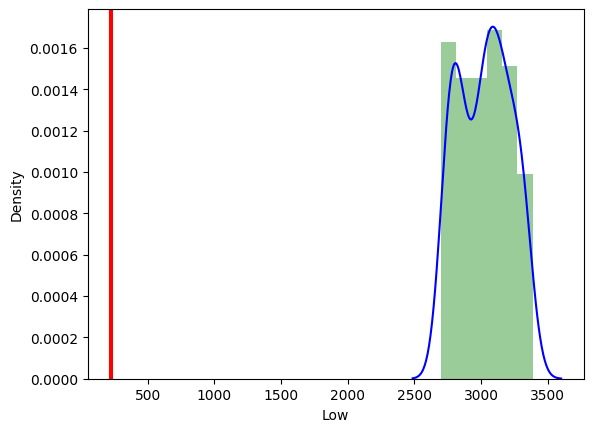

In [23]:
#16.CALL PDF PROBABILITY FUNCTION ON 'LOW' COLUMN

get_pdf_probability(dataset["Low"], 219, 230)
# get_pdf_probability(...) → calls the custom function defined earlier
# dataset["Low"] → selects the "Low" price column to analyze
# 219 → startrange parameter, the lower bound of the range
# 230 → endrange parameter, the upper bound of the range

# This code plots the distribution of the "Low" price column and calculates the probability that values fall between 219 and 230.

In [24]:
#17.DEFINE FUNCTION TO CONVERT DATA TO STANDARD NORMAL DISTRIBUTION (Z-SCORES)

def stdNBgraph(dataset):
# def → keyword used to define a new function
# stdNBgraph → name given to this custom function
# dataset → parameter the function accepts: the data column to standardize

    # Converted to standard Normal Distribution

    import seaborn as sns
    # import → keyword to load a full module
    # seaborn (module) → Python library built on matplotlib for statistical data visualization
    # as → keyword used to assign an alias
    # sns → alias name assigned to the seaborn module

    mean = dataset.mean()
    # mean → variable name storing the average value
    # = → assignment operator
    # dataset.mean() → method that calculates the mean of the dataset

    std = dataset.std()
    # std → variable name storing the standard deviation
    # = → assignment operator
    # dataset.std() → method that calculates the standard deviation of the dataset

    values = [i for i in dataset]
    # values → variable name storing a list of all data points
    # = → assignment operator
    # [i for i in dataset] → list comprehension collecting every value from dataset into a list

    z_score = [((j-mean)/std) for j in values]
    # z_score → variable name storing the list of standardized values
    # = → assignment operator
    # [((j-mean)/std) for j in values] → list comprehension applying the z-score formula (value - mean)/std to each value

    sns.distplot(z_score, kde=True)
    # sns.distplot(...) → seaborn function that draws a histogram with a distribution curve
    # z_score → the standardized data being plotted
    # kde=True → parameter enabling the Kernel Density Estimate curve (smooth distribution line)

    sum(z_score)/len(z_score)
    # sum(z_score) → adds up all the z-score values
    # / → division operator
    # len(z_score) → counts the number of z-score values
    # (this computes the mean of the z-scores, but the result isn't stored or printed)

    #z_score.std()
    # (commented out) → an unused/disabled line that would have calculated the standard deviation of z_score

# This function converts a dataset into z-scores (standard normal distribution) and plots its distribution curve, which should center around 
# mean 0 with std 1.

C:\Users\bkann\AppData\Local\Temp\ipykernel_8008\4062874946.py:36: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(z_score, kde=True)


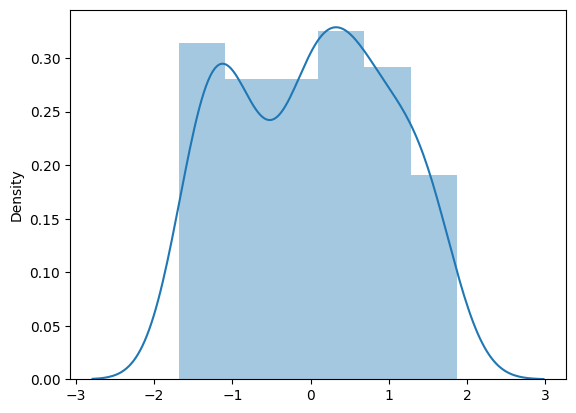

In [25]:
#18.CALL STANDARD NORMAL DISTRIBUTION FUNCTION ON 'LOW' COLUMN

stdNBgraph(dataset["Low"])
# stdNBgraph(...) → calls the custom function defined earlier
# dataset["Low"] → selects the "Low" price column to standardize and plot

# This code converts the "Low" price column into z-scores and plots its standard normal distribution curve.

In [26]:
#19.DEFINE FUNCTION TO BUILD FREQUENCY TABLE

def freqTable(columnName, dataset):
# def → keyword used to define a new function
# freqTable → name given to this custom function
# columnName, dataset → parameters the function accepts: the column name to analyze, and the DataFrame it belongs to

    import pandas as pd
    # import → keyword to load a full module
    # pandas (module) → Python library for data manipulation and analysis
    # as → keyword used to assign an alias
    # pd → alias name assigned to the pandas module

    frq = pd.DataFrame()
    # frq → variable name storing a new, empty DataFrame
    # = → assignment operator
    # pd.DataFrame() → creates an empty DataFrame to hold the frequency table

    frq["Unique_Values"] = dataset[columnName].value_counts().index
    # frq["Unique_Values"] → new column in frq to store distinct values
    # dataset[columnName] → selects the target column from dataset
    # .value_counts() → counts occurrences of each unique value
    # .index → extracts just the unique values (not their counts)

    frq["Frequency"] = dataset[columnName].value_counts().values
    # frq["Frequency"] → new column in frq to store how many times each value occurs
    # .value_counts().values → extracts just the count numbers (not the values themselves)

    frq["Relative_Fre"] = dataset[columnName].value_counts().values/len(dataset[columnName])*100
    # frq["Relative_Fre"] → new column in frq to store each value's percentage share
    # dataset[columnName].value_counts().values → the count for each unique value
    # / → division operator
    # len(dataset[columnName]) → total number of entries in the column
    # * 100 → converts the ratio into a percentage

    frq["Cumulative"] = frq["Relative_Fre"].cumsum()
    # frq["Cumulative"] → new column in frq to store running total percentage
    # frq["Relative_Fre"].cumsum() → cumulative sum method, adding each percentage to the sum of all before it

    return frq
    # return → keyword that sends a value back to wherever the function was called
    # frq → the completed frequency table DataFrame being returned

# This function builds a frequency table for a given column, showing each unique value's count, percentage share, and cumulative percentage.

In [27]:
#20.CALL FREQUENCY TABLE FUNCTION ON 'LOW' COLUMN

freqTable("Low", dataset)
# freqTable(...) → calls the custom function defined earlier
# "Low" → columnName parameter, the column to analyze
# dataset → the DataFrame containing the "Low" column

# This code generates a frequency table for the "Low" price column, showing each unique value's count, percentage share, and cumulative percentage.

,Unique_Values,Frequency,Relative_Fre,Cumulative
0,2714.839048,1,0.666667,0.666667
1,3140.451831,1,0.666667,1.333333
2,3155.248846,1,0.666667,2.000000
3,3114.428847,1,0.666667,2.666667
4,3056.070895,1,0.666667,3.333333
...,...,...,...,...
145,2890.246945,1,0.666667,97.333333
146,2889.291412,1,0.666667,98.000000
147,2916.655302,1,0.666667,98.666667
148,2985.282514,1,0.666667,99.333333


In [28]:
#21.CALL FREQUENCY TABLE FUNCTION ON 'HIGH' COLUMN

freqTable("High", dataset)
# freqTable(...) → calls the custom function defined earlier
# "High" → columnName parameter, the column to analyze
# dataset → the DataFrame containing the "High" column

# This code generates a frequency table for the "High" price column, showing each unique value's count, percentage share, and cumulative percentage.

,Unique_Values,Frequency,Relative_Fre,Cumulative
0,2747.734326,1,0.666667,0.666667
1,3194.240445,1,0.666667,1.333333
2,3211.735692,1,0.666667,2.000000
3,3159.426700,1,0.666667,2.666667
4,3139.800015,1,0.666667,3.333333
...,...,...,...,...
145,2918.827042,1,0.666667,97.333333
146,2925.776752,1,0.666667,98.000000
147,3023.070871,1,0.666667,98.666667
148,3035.536809,1,0.666667,99.333333


In [29]:
#22.STORE FREQUENCY TABLE FOR 'HIGH' COLUMN

fh = freqTable("High", dataset)
# fh → variable name used to store the resulting frequency table
# = → assignment operator
# freqTable(...) → calls the custom function defined earlier
# "High" → columnName parameter, the column to analyze
# dataset → the DataFrame containing the "High" column

# This code generates the frequency table for the "High" price column and stores it in fh for later use.

In [30]:
#23.SORT FREQUENCY TABLE BY FREQUENCY (DESCENDING)

fh.sort_values(by="Frequency", ascending=False)
# fh → the DataFrame variable holding the frequency table
# . → dot operator used to access a method belonging to the object
# sort_values(...) → DataFrame method that sorts rows based on column values
# by="Frequency" → parameter specifying which column to sort by
# ascending=False → parameter setting the sort order to descending (highest to lowest)

# This code sorts the "High" column's frequency table so the most frequently occurring values appear at the top.

,Unique_Values,Frequency,Relative_Fre,Cumulative
0,2747.734326,1,0.666667,0.666667
94,2946.839424,1,0.666667,63.333333
96,2932.407176,1,0.666667,64.666667
97,2734.384771,1,0.666667,65.333333
98,2736.379425,1,0.666667,66.000000
...,...,...,...,...
50,3242.110933,1,0.666667,34.000000
51,3237.715248,1,0.666667,34.666667
52,3255.165857,1,0.666667,35.333333
53,3272.574285,1,0.666667,36.000000


In [31]:
#24.GET UNIQUE VALUES WHERE FREQUENCY EQUALS 2 (SORTED)

fhs = fh[fh["Frequency"]==2]["Unique_Values"].sort_values(ascending=False)
# fhs → variable name storing the resulting filtered and sorted values
# = → assignment operator
# fh → the DataFrame variable holding the frequency table
# fh["Frequency"]==2 → boolean condition checking which rows have a Frequency value of exactly 2
# fh[...] → filters fh, keeping only the rows where the condition is True
# ["Unique_Values"] → selects the "Unique_Values" column from the filtered rows
# .sort_values(ascending=False) → sorts those values in descending order (highest to lowest)

# This code finds all "High" price values that occurred exactly twice, then sorts them from highest to lowest, storing the result in fhs.

In [32]:
#25.DISPLAY FILTERED & SORTED VALUES

fhs
# fhs → the variable holding the filtered "High" values (Frequency == 2), sorted descending
# (no method/operator) → simply displays fhs's contents directly in the notebook output

# This code prints out fhs — the list of "High" price values that occurred exactly twice, sorted from highest to lowest.

Series([], Name: Unique_Values, dtype: float64)